In [179]:
import imageio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.ndimage as ndi
import numpy as np

from skimage import exposure, filters, morphology, measure, color, img_as_float

/tmp/ipykernel_4934/4158476942.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread("../dataset/Assigment1/retina/normal2.jpg")


(-0.5, 1553.5, 1579.5, -0.5)

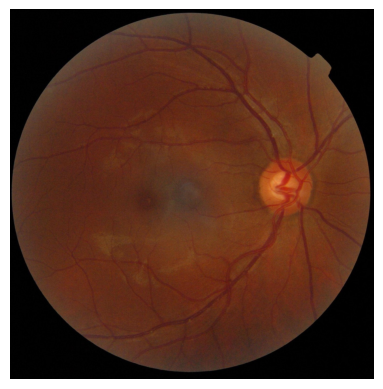

In [180]:
im = imageio.imread("../dataset/Assigment1/retina/normal2.jpg")

plt.imshow(im)
plt.axis("off")

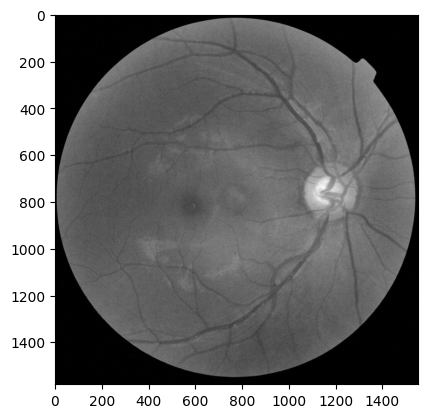

In [181]:
lab = color.rgb2lab(img_as_float(im))

L, A, B = lab[:,:,0], lab[:,:,1], lab[:,:,2]

plt.imshow(L, cmap='gray')

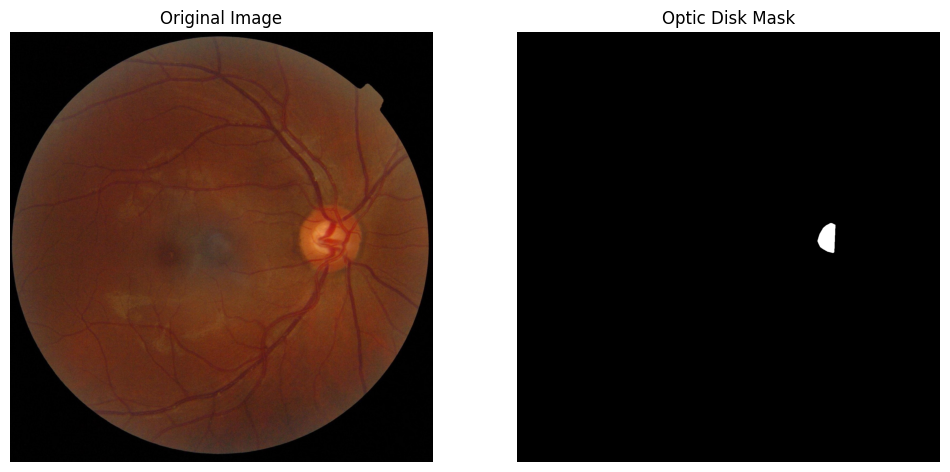

In [185]:
L_norm = L / 100.0
background = filters.gaussian(L_norm, sigma=50)
L_corrected = L_norm - background

noise = color.rgb2gray(im)
noise = noise > 0.5
# noise = morphology.erosion(noise, morphology.disk(1))

mask = L_corrected > 0.1
mask = morphology.binary_opening(mask, morphology.disk(5))
mask = morphology.remove_small_objects(mask, min_size=1000)

mask = mask & noise

mask = morphology.convex_hull_image(mask)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(im, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")  
ax[1].imshow(mask, cmap='gray')
ax[1].set_title("Optic Disk Mask")
ax[1].axis("off")
plt.show()